## Importy bibliotek:

In [1]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

%matplotlib inline

## Parametry i ekstrakcja cech HOG 
Dodanie klasy negatywnej (tło), wykorzystanie HOG do wyciagniecia informacji o krawedziach sylwetki.

In [ ]:
# Parametry okna i cech HOG (dla zbioru INRIAPerson)
WINDOW_SIZE = (64, 128) # (szerokość, wysokość)
CELL_SIZE = (8, 8)
BLOCK_SIZE = (2, 2)
NBINS = 9

def extract_hog(img):
    """Konwertuje obraz na skalę szarości i wyciąga cechy HOG"""
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, WINDOW_SIZE)
    
    features = hog(img, orientations=NBINS, pixels_per_cell=CELL_SIZE,
                   cells_per_block=BLOCK_SIZE, block_norm='L2-Hys',
                   transform_sqrt=True, feature_vector=True)
    return features

def load_data(pos_path, neg_path):
    features = []
    labels = []
    
    # Ładowanie próbek POZYTYWNYCH (sylwetki) -> Etykieta 1
    pos_files = glob.glob(os.path.join(pos_path, '*.*'))
    for file in pos_files:
        img = cv2.imread(file)
        if img is not None:
            features.append(extract_hog(img))
            labels.append(1)
            
    # Ładowanie próbek NEGATYWNYCH (tło) -> Etykieta 0
    neg_files = glob.glob(os.path.join(neg_path, '*.*'))
    for file in neg_files:
        img = cv2.imread(file)
        if img is not None:
            features.append(extract_hog(img))
            labels.append(0)
            
    return np.array(features), np.array(labels)

## Załadowanie danych i trening klasyfikatora (SVM)

In [ ]:
ścieżka_pos = 'pos'      
ścieżka_neg = 'neg_64' 

print("Ładowanie danych obrazów i ekstrakcja cech HOG...")
X, y = load_data(ścieżka_pos, ścieżka_neg)

print(f"Załadowano {len(X)} próbek.")

# Podział na zbiór uczący i testowy, by zweryfikować jakość
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Zamiast dystansu euklidesowego nauka klasyfikatora SVM
print("Trenowanie klasyfikatora Linear SVM...")
clf = LinearSVC(C=1.0, max_iter=10000)
clf.fit(X_train, y_train)

print("Gotowe. Wyniki na zbiorze testowym:")
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

Ładowanie danych obrazów i ekstrakcja cech HOG...
Załadowano 5778 próbek.
Trenowanie klasyfikatora Linear SVM...
Gotowe. Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       493
           1       0.97      0.98      0.97       663

    accuracy                           0.97      1156
   macro avg       0.97      0.96      0.97      1156
weighted avg       0.97      0.97      0.97      1156



## Struktura Sliding Window

In [ ]:
def sliding_window(image, step_size, window_size):
    """Generator zwracający wycinki obrazu w miarę przesuwania okna."""
    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

def detect_pedestrians(image, classifier, window_size=WINDOW_SIZE, step_size=16):
    """Przesuwa okno, wyciąga HOG i klasyfikuje czy to człowiek (1) czy tło (0)"""
    boxes = []
    
    for (x, y, window) in sliding_window(image, step_size, window_size):
        # Sprawdzamy, czy okno nie wyszło poza krawędzie obrazu
        if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
            continue
            
        features = extract_hog(window)
        prediction = classifier.predict([features])
        
        if prediction == 1: # czyli wykryto człowieka
            boxes.append((x, y, x + window_size[0], y + window_size[1]))
            
    return boxes

## Testowanie na większym obrazie

Testowanie na obrazie z innego zbioru

Szukanie sylwetek...
Liczba ramek przed NMS: 12
Liczba ramek po NMS: 4


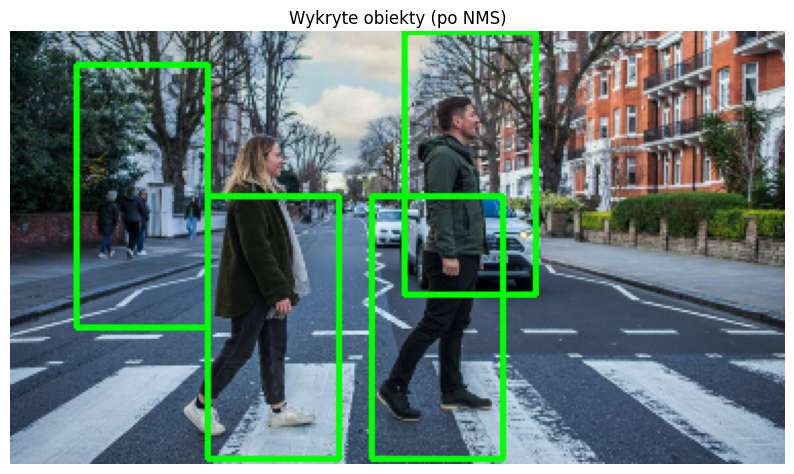

In [ ]:
from imutils.object_detection import non_max_suppression
import numpy as np

# Ścieżka do zdjęcia
test_image_path = 'test_ulica.png'

test_img = cv2.imread(test_image_path)
if test_img is not None:
    # Zmniejszenie zdjęcia (jeżeli wgl trzeba)
    test_img = cv2.resize(test_img, (0,0), fx=0.4, fy=0.4) 
    clone = test_img.copy()
    
    print("Szukanie sylwetek...")
    # 1. Pobieramy wszystkie surowe ramki z naszego detektora
    found_boxes = detect_pedestrians(test_img, clf, window_size=WINDOW_SIZE, step_size=16)
    
    # 2. Konwersja listy ramek na tablicę NumPy (wymagane przez NMS a chcialem tego użyć zeby g wykrywal ludzi)
    rects = np.array(found_boxes)
    
    # 3. NMS - Non-Maximum Suppression, czyli usuwanie nakładających się ramek 
    # overlapThresh to próg nakładania (np. 0.3 oznacza, że ramki pokrywające się w 30% zostaną połączone)
    pick = non_max_suppression(rects, probs=None, overlapThresh=0.3)
    
    print(f"Liczba ramek przed NMS: {len(rects)}")
    print(f"Liczba ramek po NMS: {len(pick)}")
    
    # 4. Rysujemy TYLKO te wyselekcjonowane ramki
    for (startX, startY, endX, endY) in pick:
        cv2.rectangle(clone, (startX, startY), (endX, endY), (0, 255, 0), 2)
        
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(clone, cv2.COLOR_BGR2RGB))
    plt.title("Wykryte obiekty (po NMS)")
    plt.axis("off")
    plt.show()
else:
    print("Nie można załadować obrazka! Sprawdź ścieżkę.")